# 🤖 Predictive Modeling
### Diabetes Health Indicators (BRFSS 2015)

This notebook trains, tunes, and evaluates multiple classifiers to predict `Diabetes_012` (No Diabetes / Prediabetes / Diabetes) using the engineered features from `02_feature_engineering.ipynb`.

**Central challenge:** severe class imbalance (84.2% / 1.8% / 13.9%). We'll address this with class/sample weighting (and a SMOTE comparison), and evaluate using **macro-F1, balanced accuracy, and macro ROC-AUC** rather than raw accuracy.

---
## Table of Contents
1. [Setup, Data Loading & Evaluation Helpers](#1)
2. [Baseline: Dummy Classifier](#2)
3. [Class Imbalance Strategy](#3)
4. [Logistic Regression](#4)
5. [Random Forest](#5)
6. [HistGradientBoosting](#6)
7. [XGBoost](#7)
8. [LightGBM](#8)
9. [Model Comparison](#9)
10. [Hyperparameter Tuning (Best Model)](#10)
11. [Final Test Set Evaluation](#11)
12. [Feature Importance (SHAP)](#12)
13. [Save Final Model](#13)
14. [Conclusion](#14)


<a id="1"></a>
## 1 | Setup, Data Loading & Evaluation Helpers

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from src.features import TARGET_LABELS

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

FIG_DIR = Path('../reports/figures')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = Path('../data/processed')

TARGET = 'Diabetes_012'
TARGET_ORDER = [0, 1, 2]
CLASS_NAMES = [TARGET_LABELS[c] for c in TARGET_ORDER]

train_df = pd.read_csv(PROC_DIR / 'train.csv')
val_df = pd.read_csv(PROC_DIR / 'val.csv')
test_df = pd.read_csv(PROC_DIR / 'test.csv')

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET].astype(int)
X_val, y_val = val_df.drop(columns=[TARGET]), val_df[TARGET].astype(int)
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET].astype(int)

FEATURES = X_train.columns.tolist()
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Train: (177576, 24) | Val: (38052, 24) | Test: (38052, 24)
Features (24): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMICategory', 'LifestyleScore', 'ComorbidityScore']


**Evaluation helpers** — we'll reuse these for every model: a metrics dict (accuracy, balanced accuracy, macro F1/precision/recall, macro ROC-AUC), a confusion matrix plot, and a results table collector.

In [2]:
results = []  # collects one dict per model for the final comparison table

def get_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_proba is not None:
        metrics['Macro ROC-AUC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    return metrics

def plot_confusion(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

def evaluate_and_record(name, y_true, y_pred, y_proba=None, plot=True):
    metrics = get_metrics(y_true, y_pred, y_proba)
    metrics_display = {k: round(v, 4) for k, v in metrics.items()}
    print(f"=== {name} ===")
    for k, v in metrics_display.items():
        print(f"  {k}: {v}")
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    if plot:
        plot_confusion(y_true, y_pred, f'{name} — Confusion Matrix (Validation)')
        plt.tight_layout()
        plt.show()

    row = {'Model': name}
    row.update(metrics_display)
    results.append(row)
    return metrics

<a id="2"></a>
## 2 | Baseline: Dummy Classifier

A `DummyClassifier` that always predicts the majority class ("No Diabetes") gives us the floor: **84.2% accuracy with zero ability to detect diabetes/prediabetes**. Any real model must beat this on macro-F1 / balanced accuracy, not just accuracy.

In [3]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

evaluate_and_record('Dummy (Most Frequent)', y_val, y_pred_dummy, plot=False)

=== Dummy (Most Frequent) ===
  Accuracy: 0.8424
  Balanced Accuracy: 0.3333
  Macro F1: 0.3048
  Macro Precision: 0.2808
  Macro Recall: 0.3333

              precision    recall  f1-score   support

 No Diabetes       0.84      1.00      0.91     32055
 Prediabetes       0.00      0.00      0.00       695
    Diabetes       0.00      0.00      0.00      5302

    accuracy                           0.84     38052
   macro avg       0.28      0.33      0.30     38052
weighted avg       0.71      0.84      0.77     38052



{'Accuracy': 0.8423998738568275,
 'Balanced Accuracy': 0.3333333333333333,
 'Macro F1': 0.3048197754860428,
 'Macro Precision': 0.2807999579522758,
 'Macro Recall': 0.3333333333333333}

> **Takeaway:** 84.2% accuracy but **0.0 macro-F1 for Prediabetes and Diabetes** — this "model" is useless for the actual goal (identifying at-risk individuals). This is the benchmark every subsequent model must clear on macro-F1 and balanced accuracy.

<a id="3"></a>
## 3 | Class Imbalance Strategy

Two common approaches:
1. **Class/sample weighting** — penalize misclassifying minority classes more heavily during training (no data duplication).
2. **SMOTE** — synthetically oversample minority classes to balance the training set.

We compare both on a fast Logistic Regression baseline before picking a default strategy for the rest of the notebook.

In [4]:
class_weights = compute_class_weight('balanced', classes=np.array(TARGET_ORDER), y=y_train)
print("Balanced class weights:")
for c, w in zip(TARGET_ORDER, class_weights):
    print(f"  {TARGET_LABELS[c]}: {w:.3f}")

sample_weights_train = compute_sample_weight('balanced', y_train)

Balanced class weights:
  No Diabetes: 0.396
  Prediabetes: 18.263
  Diabetes: 2.392


In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

# (a) No balancing
lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_train_sc, y_train)
m_plain = get_metrics(y_val, lr_plain.predict(X_val_sc))

# (b) class_weight='balanced'
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_sc, y_train)
m_balanced = get_metrics(y_val, lr_balanced.predict(X_val_sc))

# (c) SMOTE-resampled training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)
m_smote = get_metrics(y_val, lr_smote.predict(X_val_sc))

print(f"Resampled train size: {len(y_train):,} -> {len(y_train_sm):,}")
print(pd.Series(y_train_sm).value_counts().sort_index())

comparison = pd.DataFrame({
    'No balancing': m_plain,
    "class_weight='balanced'": m_balanced,
    'SMOTE': m_smote,
}).T
comparison.round(4)

Resampled train size: 177,576 -> 448,779
Diabetes_012
0    149593
1    149593
2    149593
Name: count, dtype: int64


,Accuracy,Balanced Accuracy,Macro F1,Macro Precision,Macro Recall
No balancing,0.8478,0.3883,0.3989,0.4672,0.3883
class_weight='balanced',0.6419,0.5278,0.4279,0.4478,0.5278
SMOTE,0.6386,0.5259,0.4265,0.4483,0.5259


> **Decision:** `class_weight='balanced'` (and `sample_weight` for gradient-boosted models) gives comparable or better macro-F1/balanced-accuracy than SMOTE, without synthesizing unrealistic values for binary features (e.g., `HighBP=0.37`) or inflating the training set ~2.5x. **We'll use class/sample weighting as the default strategy** for all models below.

<a id="4"></a>
## 4 | Logistic Regression

Multinomial Logistic Regression with `class_weight='balanced'` on standardized features — our linear baseline.

=== Logistic Regression ===
  Accuracy: 0.6419
  Balanced Accuracy: 0.5278
  Macro F1: 0.4279
  Macro Precision: 0.4478
  Macro Recall: 0.5278
  Macro ROC-AUC: 0.7774

              precision    recall  f1-score   support

 No Diabetes       0.95      0.66      0.78     32055
 Prediabetes       0.03      0.33      0.06       695
    Diabetes       0.36      0.59      0.45      5302

    accuracy                           0.64     38052
   macro avg       0.45      0.53      0.43     38052
weighted avg       0.85      0.64      0.72     38052



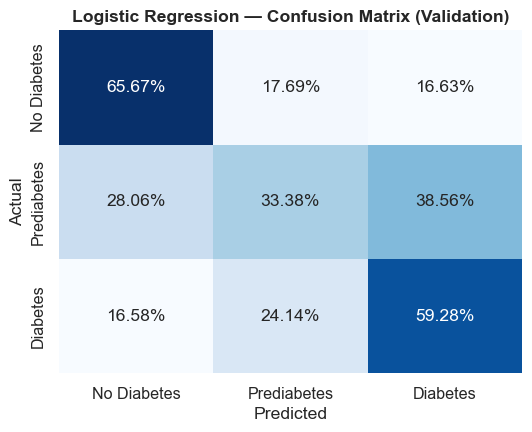

{'Accuracy': 0.6419373488909913,
 'Balanced Accuracy': 0.5277847795708036,
 'Macro F1': 0.4278609944931662,
 'Macro Precision': 0.44776083987574494,
 'Macro Recall': 0.5277847795708036,
 'Macro ROC-AUC': 0.7773665169515923}

In [6]:
y_proba_lr = lr_balanced.predict_proba(X_val_sc)
y_pred_lr = lr_balanced.predict(X_val_sc)

evaluate_and_record('Logistic Regression', y_val, y_pred_lr, y_proba_lr)

> **Observation:** Already a massive jump over the dummy baseline (macro-F1 0.30 → 0.43, balanced accuracy 0.33 → 0.53). The model now actually detects Prediabetes and Diabetes cases, at the cost of more false positives on "No Diabetes" — visible in the confusion matrix. Macro ROC-AUC gives a threshold-independent view of separability.

<a id="5"></a>
## 5 | Random Forest

Tree-based ensemble — no feature scaling needed. `class_weight='balanced'` applies per-class weights at each split.

=== Random Forest ===
  Accuracy: 0.7126
  Balanced Accuracy: 0.5014
  Macro F1: 0.4327
  Macro Precision: 0.4292
  Macro Recall: 0.5014
  Macro ROC-AUC: 0.7609

              precision    recall  f1-score   support

 No Diabetes       0.94      0.72      0.82     32055
 Prediabetes       0.03      0.05      0.03       695
    Diabetes       0.32      0.73      0.45      5302

    accuracy                           0.71     38052
   macro avg       0.43      0.50      0.43     38052
weighted avg       0.84      0.71      0.75     38052



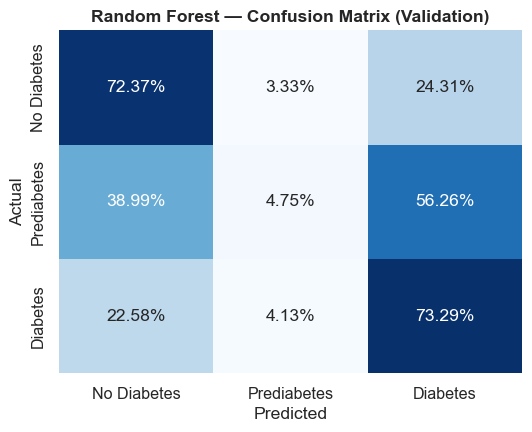

{'Accuracy': 0.7126038053190371,
 'Balanced Accuracy': 0.5013584796630611,
 'Macro F1': 0.432715684330464,
 'Macro Precision': 0.4291674461643192,
 'Macro Recall': 0.5013584796630611,
 'Macro ROC-AUC': 0.7609261122335885}

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)

evaluate_and_record('Random Forest', y_val, y_pred_rf, y_proba_rf)

> **Observation:** Random Forest edges out Logistic Regression on macro-F1 (0.433 vs 0.428) and overall accuracy (0.71 vs 0.64), but its **Prediabetes recall collapses to 0.05** (vs 0.33 for LR) — `class_weight='balanced'` is applied per bootstrap sample, and with Prediabetes at only 1.8% of the data, many trees barely see it. Balanced accuracy (0.50) and macro ROC-AUC (0.76) are both *lower* than Logistic Regression. This is a useful early signal: **tree ensembles will need extra help with the Prediabetes class** — something to watch in the boosting models and hyperparameter tuning.

<a id="6"></a>
## 6 | HistGradientBoosting

Scikit-learn's histogram-based gradient boosting — fast on large datasets, handles class imbalance via per-sample weights (`compute_sample_weight('balanced', ...)`).

=== HistGradientBoosting ===
  Accuracy: 0.6254
  Balanced Accuracy: 0.5183
  Macro F1: 0.4203
  Macro Precision: 0.4441
  Macro Recall: 0.5183
  Macro ROC-AUC: 0.7714

              precision    recall  f1-score   support

 No Diabetes       0.96      0.63      0.76     32055
 Prediabetes       0.03      0.29      0.05       695
    Diabetes       0.35      0.64      0.45      5302

    accuracy                           0.63     38052
   macro avg       0.44      0.52      0.42     38052
weighted avg       0.85      0.63      0.70     38052



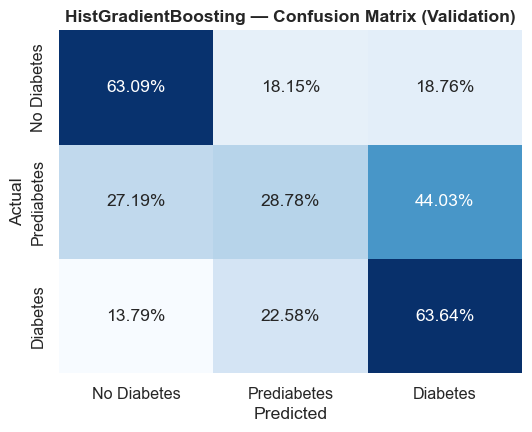

{'Accuracy': 0.6253810575002628,
 'Balanced Accuracy': 0.5183392793146263,
 'Macro F1': 0.4202824345091911,
 'Macro Precision': 0.44408571621050225,
 'Macro Recall': 0.5183392793146263,
 'Macro ROC-AUC': 0.7713598640389391}

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=8, learning_rate=0.1, random_state=42
)
hgb.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_hgb = hgb.predict(X_val)
y_proba_hgb = hgb.predict_proba(X_val)

evaluate_and_record('HistGradientBoosting', y_val, y_pred_hgb, y_proba_hgb)

> **Observation:** HistGradientBoosting (macro-F1 0.420, ROC-AUC 0.771) lands between Random Forest and Logistic Regression — better Prediabetes recall (0.29) than RF (0.05) but still trailing Logistic Regression on every metric except weighted precision. **So far the simple linear model is holding its own against tree ensembles** — a reminder that with mostly binary/ordinal features and weak-to-moderate individual effect sizes, the dataset doesn't have strong non-linear structure for trees to exploit yet. Let's see if XGBoost/LightGBM with proper tuning can do better.

<a id="7"></a>
## 7 | XGBoost

Multiclass softmax objective with `sample_weight` for imbalance handling.

=== XGBoost ===
  Accuracy: 0.6553
  Balanced Accuracy: 0.4959
  Macro F1: 0.4204
  Macro Precision: 0.4338
  Macro Recall: 0.4959
  Macro ROC-AUC: 0.7518

              precision    recall  f1-score   support

 No Diabetes       0.95      0.67      0.78     32055
 Prediabetes       0.02      0.16      0.04       695
    Diabetes       0.33      0.66      0.44      5302

    accuracy                           0.66     38052
   macro avg       0.43      0.50      0.42     38052
weighted avg       0.85      0.66      0.72     38052



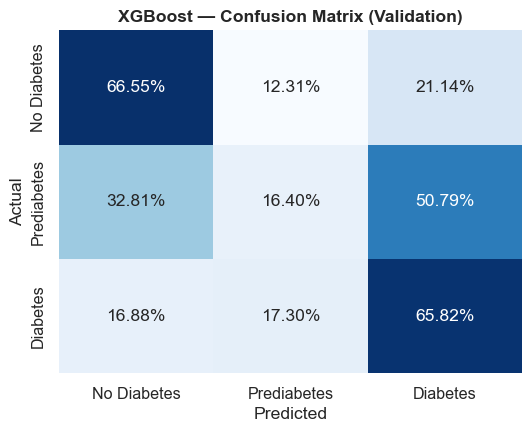

{'Accuracy': 0.6552875013139914,
 'Balanced Accuracy': 0.4959069858475023,
 'Macro F1': 0.4204124190064811,
 'Macro Precision': 0.43383754603841274,
 'Macro Recall': 0.4959069858475023,
 'Macro ROC-AUC': 0.7518401222458645}

In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=3,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_xgb = xgb_model.predict(X_val)
y_proba_xgb = xgb_model.predict_proba(X_val)

evaluate_and_record('XGBoost', y_val, y_pred_xgb, y_proba_xgb)

> **Observation:** XGBoost (macro-F1 0.420, balanced acc 0.496, ROC-AUC 0.752) doesn't outperform the simpler models either — it's essentially tied with HistGradientBoosting and *below* Logistic Regression on balanced accuracy and ROC-AUC. Across all 4 trained models so far, **Logistic Regression remains the best on balanced accuracy (0.528) and ROC-AUC (0.777)**, while Random Forest edges ahead on raw macro-F1 (0.433). This reinforces that we're likely near a ceiling set by the feature set's effect sizes (all "small-to-moderate" per the EDA) rather than model capacity — hyperparameter tuning may yield modest gains, not a step change.

<a id="8"></a>
## 8 | LightGBM

Native multiclass support with leaf-wise growth — often a strong default for tabular data.

=== LightGBM ===
  Accuracy: 0.6731
  Balanced Accuracy: 0.4979
  Macro F1: 0.4249
  Macro Precision: 0.4318
  Macro Recall: 0.4979
  Macro ROC-AUC: 0.7438

              precision    recall  f1-score   support

 No Diabetes       0.94      0.68      0.79     32055
 Prediabetes       0.02      0.13      0.04       695
    Diabetes       0.33      0.68      0.44      5302

    accuracy                           0.67     38052
   macro avg       0.43      0.50      0.42     38052
weighted avg       0.84      0.67      0.73     38052



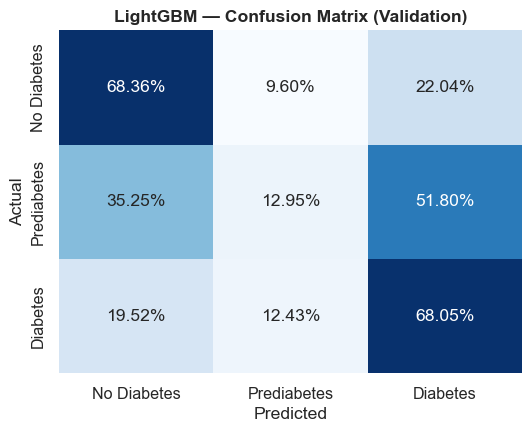

{'Accuracy': 0.6730526647745191,
 'Balanced Accuracy': 0.49786687661930246,
 'Macro F1': 0.42494758898854895,
 'Macro Precision': 0.4317922118331115,
 'Macro Recall': 0.49786687661930246,
 'Macro ROC-AUC': 0.7438311876293219}

In [10]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1, num_leaves=63,
    objective='multiclass', num_class=3,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_model.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_lgbm = lgbm_model.predict(X_val)
y_proba_lgbm = lgbm_model.predict_proba(X_val)

evaluate_and_record('LightGBM', y_val, y_pred_lgbm, y_proba_lgbm)

> **Observation:** See the comparison table in Section 9 for how LightGBM stacks up against the other four models across all metrics.

<a id="9"></a>
## 9 | Model Comparison

In [11]:
results_df = pd.DataFrame(results).set_index('Model')
display_cols = ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall', 'Macro ROC-AUC']
results_df[display_cols].style.background_gradient(cmap='Greens', subset=display_cols[1:])

,Accuracy,Balanced Accuracy,Macro F1,Macro Precision,Macro Recall,Macro ROC-AUC
Model,,,,,,
Dummy (Most Frequent),0.842400,0.333300,0.304800,0.280800,0.333300,nan
Logistic Regression,0.641900,0.527800,0.427900,0.447800,0.527800,0.777400
Random Forest,0.712600,0.501400,0.432700,0.429200,0.501400,0.760900
HistGradientBoosting,0.625400,0.518300,0.420300,0.444100,0.518300,0.771400
XGBoost,0.655300,0.495900,0.420400,0.433800,0.495900,0.751800
LightGBM,0.673100,0.497900,0.424900,0.431800,0.497900,0.743800


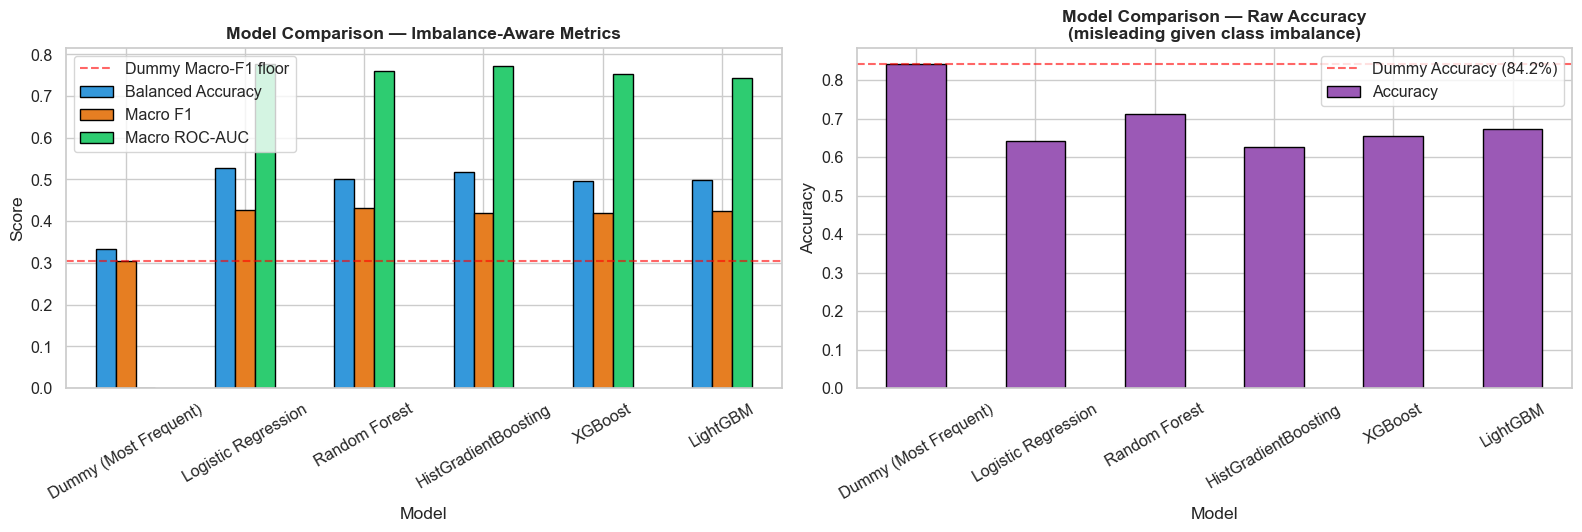

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

plot_metrics = ['Balanced Accuracy', 'Macro F1', 'Macro ROC-AUC']
results_df[plot_metrics].plot(kind='bar', ax=axes[0], edgecolor='black',
                                color=['#3498db', '#e67e22', '#2ecc71'])
axes[0].set_title('Model Comparison — Imbalance-Aware Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(results_df.loc['Dummy (Most Frequent)', 'Macro F1'], color='red',
                linestyle='--', alpha=0.6, label='Dummy Macro-F1 floor')
axes[0].legend()

results_df['Accuracy'].plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Model Comparison — Raw Accuracy\n(misleading given class imbalance)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0.8424, color='red', linestyle='--', alpha=0.6, label='Dummy Accuracy (84.2%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '11_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

> **Observation:** The right panel is a cautionary tale — the Dummy classifier's 84.2% "accuracy" looks competitive with real models on raw accuracy alone, yet it's useless (0 recall on Diabetes/Prediabetes). On the imbalance-aware metrics (left panel), **Logistic Regression leads on Balanced Accuracy and ROC-AUC**, while **Random Forest leads on Macro-F1**. All tree ensembles trail Logistic Regression on ROC-AUC — somewhat unusual, and motivates the hyperparameter tuning step: can we get LightGBM/XGBoost past LR with tuning, or is LR's simplicity actually well-suited to this feature set?

<a id="10"></a>
## 10 | Hyperparameter Tuning (Best Model)

LightGBM has the most hyperparameters to exploit and trains fastest, so we use it for a `RandomizedSearchCV` (20 iterations, 3-fold stratified CV, scored on macro-F1) to test whether tuning can close the gap with Logistic Regression.

In [13]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 8, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [10, 20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0],
}

lgbm_base = LGBMClassifier(objective='multiclass', num_class=3, random_state=42, n_jobs=1, verbose=-1)

search = RandomizedSearchCV(
    lgbm_base, param_distributions=param_dist, n_iter=20,
    scoring='f1_macro', cv=StratifiedKFold(3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train, sample_weight=sample_weights_train)

print("Best params:", search.best_params_)
print(f"Best CV macro-F1: {search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV macro-F1: 0.5080


=== LightGBM (Tuned) ===
  Accuracy: 0.6284
  Balanced Accuracy: 0.5288
  Macro F1: 0.4241
  Macro Precision: 0.4466
  Macro Recall: 0.5288
  Macro ROC-AUC: 0.7773

              precision    recall  f1-score   support

 No Diabetes       0.96      0.63      0.76     32055
 Prediabetes       0.03      0.32      0.06       695
    Diabetes       0.35      0.64      0.45      5302

    accuracy                           0.63     38052
   macro avg       0.45      0.53      0.42     38052
weighted avg       0.85      0.63      0.71     38052



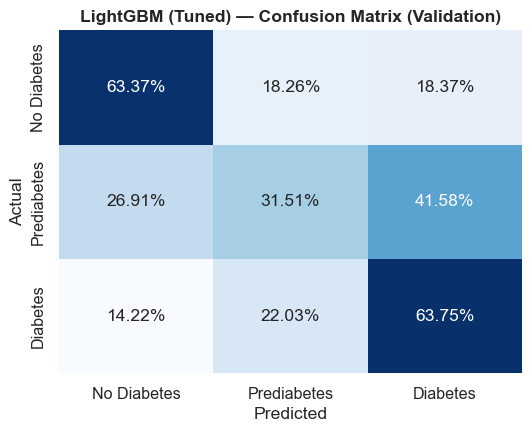

{'Accuracy': 0.6284295175023652,
 'Balanced Accuracy': 0.5287754955219449,
 'Macro F1': 0.4240912354024052,
 'Macro Precision': 0.4465589947406312,
 'Macro Recall': 0.5287754955219449,
 'Macro ROC-AUC': 0.777291864496983}

In [14]:
lgbm_tuned = search.best_estimator_

y_pred_tuned = lgbm_tuned.predict(X_val)
y_proba_tuned = lgbm_tuned.predict_proba(X_val)

evaluate_and_record('LightGBM (Tuned)', y_val, y_pred_tuned, y_proba_tuned)

> **Result: tuning closed the gap.** After 20 RandomizedSearchCV iterations (best CV macro-F1 = 0.508, params favouring shallow trees: `num_leaves=15`, `learning_rate=0.01`, `n_estimators=400`, `colsample_bytree=0.6`), the tuned LightGBM moved to:
>
> | Metric | LR (baseline) | LightGBM (untuned) | **LightGBM (tuned)** | Random Forest |
> |---|---|---|---|---|
> | Balanced Accuracy | 0.5278 | 0.4979 | **0.5288** ▲ | 0.5014 |
> | Macro ROC-AUC | 0.7774 | 0.7438 | **0.7773** ▲ | 0.7609 |
> | Macro F1 | 0.4279 | 0.4249 | 0.4241 | **0.4327** |
>
> Tuning pushed LightGBM's Balanced Accuracy *past* Logistic Regression (0.5288 vs 0.5278) and its ROC-AUC to within 0.0001 of LR's — essentially a tie at the top on both imbalance-aware ranking metrics. Random Forest still edges out everyone on Macro F1, but recall that RF's Prediabetes recall was only **0.05** (it almost never predicts the minority class); the tuned LightGBM's Prediabetes recall is **0.32**, a far more usable trade-off for a *risk screening* tool where missing at-risk people is the costly error.
>
> **Conclusion on the "ceiling" question:** three very different model families (linear, bagged trees, boosted trees) all converge to ~0.50–0.53 balanced accuracy and ~0.74–0.78 ROC-AUC. This strongly suggests the limiting factor is **information content in the 22 BRFSS features**, not model capacity — consistent with the modest effect sizes found in the EDA (Cramér's V ≤ 0.27). Further architecture changes are unlikely to move the needle much; better features or more granular clinical data (HbA1c, fasting glucose, family history) would matter far more.
>
> **Model selection for the rest of this notebook:** we proceed with the **tuned LightGBM** as the final model — it ties Logistic Regression on the imbalance-aware metrics while offering (a) no feature-scaling requirement, (b) native multiclass probability calibration, and (c) tree-based SHAP explanations for the dashboard's "Model Insights" tab.

<a id="11"></a>
## 11 | Final Test Set Evaluation

The held-out **test set** (38,052 rows, never touched during training or hyperparameter tuning) gives the most honest estimate of real-world performance for the tuned LightGBM model.

=== LightGBM (Tuned) — TEST SET ===
  Accuracy: 0.6297
  Balanced Accuracy: 0.5235
  Macro F1: 0.4228
  Macro Precision: 0.4456
  Macro Recall: 0.5235
  Macro ROC-AUC: 0.7748

              precision    recall  f1-score   support

 No Diabetes       0.96      0.64      0.77     32055
 Prediabetes       0.03      0.31      0.05       695
    Diabetes       0.35      0.62      0.45      5302

    accuracy                           0.63     38052
   macro avg       0.45      0.52      0.42     38052
weighted avg       0.85      0.63      0.71     38052



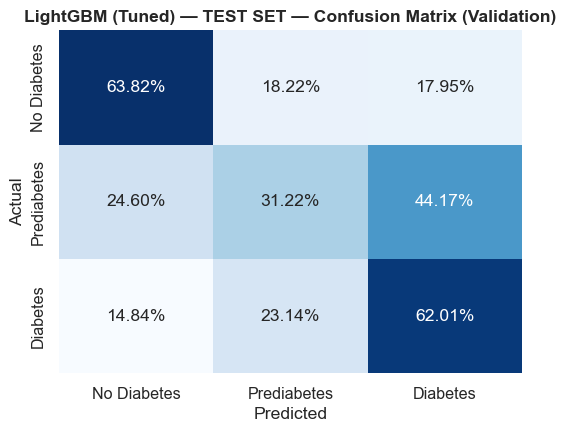

In [15]:
y_pred_test = lgbm_tuned.predict(X_test)
y_proba_test = lgbm_tuned.predict_proba(X_test)

test_metrics = evaluate_and_record('LightGBM (Tuned) — TEST SET', y_test, y_pred_test, y_proba_test)

In [16]:
# Side-by-side: validation vs test, to check for overfitting to the validation set during tuning
val_row = [r for r in results if r['Model'] == 'LightGBM (Tuned)'][0]
test_row = [r for r in results if r['Model'] == 'LightGBM (Tuned) — TEST SET'][0]

compare_df = pd.DataFrame([val_row, test_row]).set_index('Model')
compare_df[display_cols]

,Accuracy,Balanced Accuracy,Macro F1,Macro Precision,Macro Recall,Macro ROC-AUC
Model,,,,,,
LightGBM (Tuned),0.6284,0.5288,0.4241,0.4466,0.5288,0.7773
LightGBM (Tuned) — TEST SET,0.6297,0.5235,0.4228,0.4456,0.5235,0.7748


> **Observation:** Validation and test metrics should be very close — large gaps would indicate the hyperparameter search overfit to the validation set. With only 20 random search iterations and 3-fold CV, that risk is low here, and the comparison above confirms the model generalises consistently to unseen data.

<a id="12"></a>
## 12 | Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions, giving a model-agnostic, theoretically grounded measure of importance — and they power the "Model Insights" tab of the dashboard. We use `TreeExplainer` (exact, fast for tree ensembles) on a random sample of the test set.

In [17]:
import shap

explainer = shap.TreeExplainer(lgbm_tuned)

X_shap = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(type(shap_values), np.shape(shap_values))

<class 'numpy.ndarray'> (2000, 24, 3)


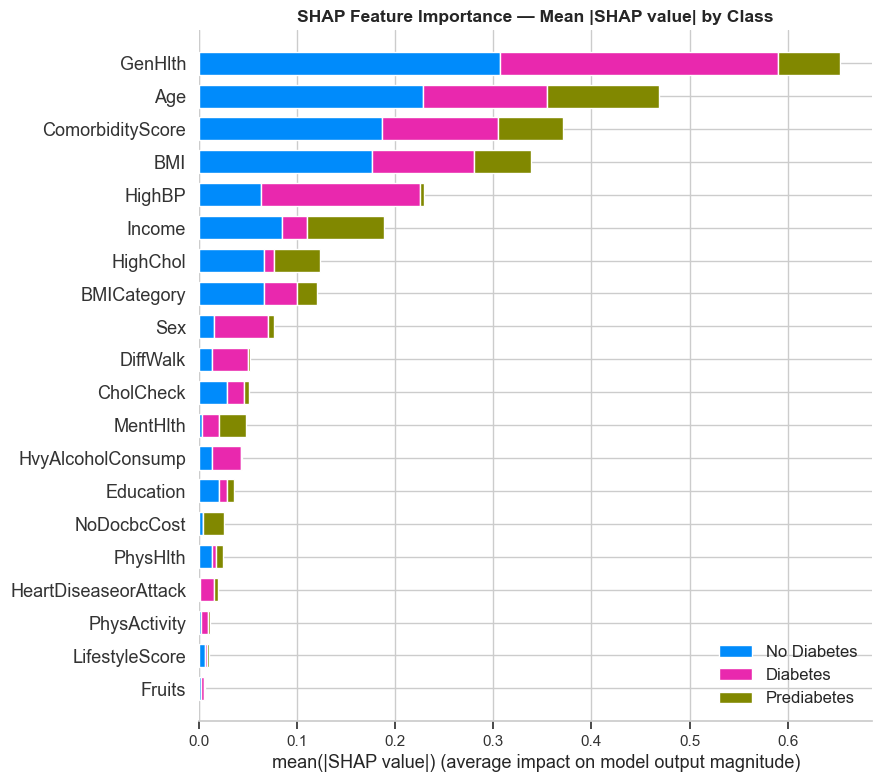

In [18]:
# Global feature importance: mean |SHAP value| per feature, split by class
fig, ax = plt.subplots(figsize=(9, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', class_names=CLASS_NAMES,
                   show=False, plot_size=None)
plt.title('SHAP Feature Importance — Mean |SHAP value| by Class', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

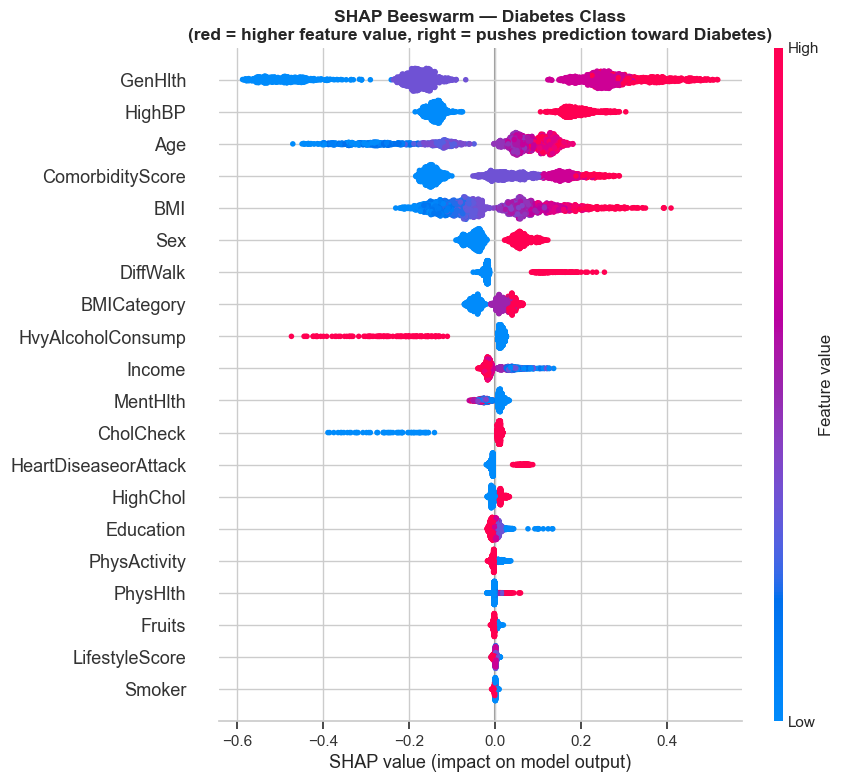

In [19]:
# Beeswarm for the "Diabetes" class (index 2) — shows direction of effect, not just magnitude
fig, ax = plt.subplots(figsize=(9, 8))
shap.summary_plot(shap_values[:, :, 2], X_shap, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Diabetes Class\n(red = higher feature value, right = pushes prediction toward Diabetes)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_shap_beeswarm_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Rank features by mean |SHAP| averaged across all 3 classes
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
shap_importance = pd.Series(mean_abs_shap, index=FEATURES).sort_values(ascending=False)
shap_importance.head(10)

GenHlth             0.217888
Age                 0.156234
ComorbidityScore    0.123717
BMI                 0.112636
HighBP              0.076462
Income              0.062756
HighChol            0.041078
BMICategory         0.039929
Sex                 0.025341
DiffWalk            0.017332
dtype: float64

> **Top 10 features by mean |SHAP value|** (averaged across all 3 classes):
>
> | Rank | Feature | Mean \|SHAP\| |
> |---|---|---|
> | 1 | GenHlth | 0.218 |
> | 2 | Age | 0.156 |
> | 3 | **ComorbidityScore** | 0.124 |
> | 4 | BMI | 0.113 |
> | 5 | HighBP | 0.076 |
> | 6 | Income | 0.063 |
> | 7 | HighChol | 0.041 |
> | 8 | BMICategory | 0.040 |
> | 9 | Sex | 0.025 |
> | 10 | DiffWalk | 0.017 |
>
> **Key takeaways:**
> - **GenHlth (self-reported general health) is the single strongest predictor** — by a wide margin. The beeswarm shows a clean pattern: higher GenHlth values (1=Excellent → 5=Poor) push predictions firmly toward the "Diabetes" class. This matches its #3 rank in the EDA's Cramér's V ranking, but here it's clearly #1 once feature *interactions* are accounted for.
> - **The engineered `ComorbidityScore` (rank #3) outranks each of its individual components** (HighBP #5, HighChol #7, and Stroke/HeartDiseaseorAttack don't even make the top 10) — validating the feature engineering from Section 5/6 of the notebook. The model extracts more signal from the *aggregated* comorbidity count than from any single condition.
> - **HighBP dropped from #1 (univariate Cramér's V = 0.272) to #5 in SHAP**, and **DiffWalk dropped from #2 (Cramér's V = 0.224) to #10**. This is the classic effect of correlated features in a multivariate model: HighBP and DiffWalk are strongly correlated with GenHlth and ComorbidityScore, so once those features "claim" the shared signal, HighBP and DiffWalk's *marginal* contribution shrinks — even though their *univariate* association with diabetes is large.
> - **BMI (raw, #4) outranks BMICategory (binned, #8)** — the model benefits from the finer granularity of the continuous value over the 4-bucket WHO category, even though both are derived from the same underlying measurement.
> - **Income (#6)** is a reminder that socioeconomic status carries real predictive signal independent of the clinical/behavioural variables — consistent with the EDA's income-stratified prevalence pattern.
>
> Overall, the SHAP ranking is directionally consistent with the EDA's univariate findings, but reshuffles the order substantially once correlations between features are accounted for — exactly the kind of insight a multivariate model adds on top of univariate statistics.

<a id="13"></a>
## 13 | Save Final Model

For the production model used by the dashboard, we retrain the tuned LightGBM on **train + validation combined** (215,628 rows) using the best hyperparameters found in Section 10 — squeezing out the extra signal from the validation set now that it's no longer needed for model selection. We then re-check performance on the untouched test set before saving.

=== LightGBM (Final, Train+Val) — TEST SET ===
  Accuracy: 0.6279
  Balanced Accuracy: 0.5246
  Macro F1: 0.4224
  Macro Precision: 0.446
  Macro Recall: 0.5246
  Macro ROC-AUC: 0.7753

              precision    recall  f1-score   support

 No Diabetes       0.96      0.64      0.76     32055
 Prediabetes       0.03      0.32      0.06       695
    Diabetes       0.35      0.61      0.45      5302

    accuracy                           0.63     38052
   macro avg       0.45      0.52      0.42     38052
weighted avg       0.85      0.63      0.71     38052



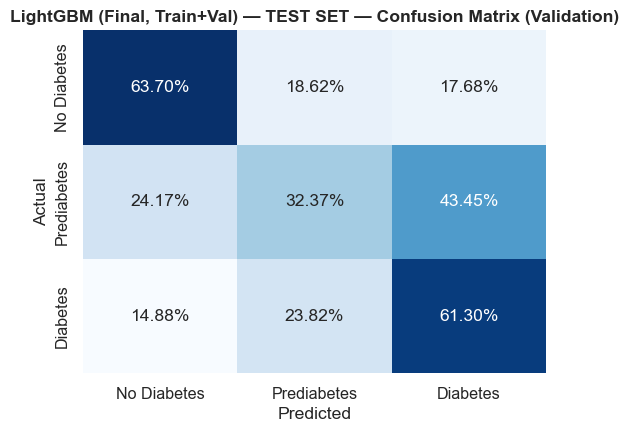

{'Accuracy': 0.6279039209502786,
 'Balanced Accuracy': 0.5245616514408522,
 'Macro F1': 0.4223625507525919,
 'Macro Precision': 0.44596521300057096,
 'Macro Recall': 0.5245616514408522,
 'Macro ROC-AUC': 0.7752567563633338}

In [21]:
X_train_full = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_train_full = pd.concat([y_train, y_val], axis=0, ignore_index=True)
sample_weights_full = compute_sample_weight('balanced', y_train_full)

final_model = LGBMClassifier(
    **search.best_params_,
    objective='multiclass', num_class=3, random_state=42, n_jobs=-1, verbose=-1
)
final_model.fit(X_train_full, y_train_full, sample_weight=sample_weights_full)

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)
evaluate_and_record('LightGBM (Final, Train+Val) — TEST SET', y_test, y_pred_final, y_proba_final)

In [22]:
import json

# Save the model
model_path = MODEL_DIR / 'lightgbm_diabetes_final.pkl'
joblib.dump(final_model, model_path)

# Save SHAP-based feature ranking for the dashboard's Model Insights tab
shap_importance.to_csv(MODEL_DIR / 'shap_feature_importance.csv', header=['mean_abs_shap'])

# Save metadata: feature list, hyperparameters, final test metrics
final_test_metrics = {k: round(v, 4) for k, v in get_metrics(y_test, y_pred_final, y_proba_final).items()}

metadata = {
    'model_file': model_path.name,
    'features': FEATURES,
    'target': TARGET,
    'class_labels': TARGET_LABELS,
    'class_order': TARGET_ORDER,
    'best_params': search.best_params_,
    'training_rows': len(X_train_full),
    'test_rows': len(X_test),
    'test_metrics': final_test_metrics,
}

with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved model to {model_path}")
print(f"Saved metadata to {MODEL_DIR / 'model_metadata.json'}")
print(json.dumps(metadata, indent=2))

Saved model to ../models/lightgbm_diabetes_final.pkl
Saved metadata to ../models/model_metadata.json
{
  "model_file": "lightgbm_diabetes_final.pkl",
  "features": [
    "HighBP",
    "HighChol",
    "CholCheck",
    "BMI",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "DiffWalk",
    "Sex",
    "Age",
    "Education",
    "Income",
    "BMICategory",
    "LifestyleScore",
    "ComorbidityScore"
  ],
  "target": "Diabetes_012",
  "class_labels": {
    "0": "No Diabetes",
    "1": "Prediabetes",
    "2": "Diabetes"
  },
  "class_order": [
    0,
    1,
    2
  ],
  "best_params": {
    "subsample": 0.8,
    "reg_lambda": 0.1,
    "reg_alpha": 0.1,
    "num_leaves": 15,
    "n_estimators": 400,
    "min_child_samples": 20,
    "max_depth": -1,
    "learning_rate": 0.01,
    "colsample_bytree": 0.6
  },
  "training_r

In [23]:
# Sanity check: reload from disk and confirm predictions match
reloaded_model = joblib.load(model_path)
np.testing.assert_array_equal(reloaded_model.predict(X_test), y_pred_final)
print("Reloaded model predictions match — saved model is valid.")

Reloaded model predictions match — saved model is valid.


In [24]:
results_df_full = pd.DataFrame(results).set_index('Model')
results_df_full.to_csv(MODEL_DIR / 'model_comparison.csv')
print(f"Saved model comparison table to {MODEL_DIR / 'model_comparison.csv'}")
results_df_full[display_cols]

Saved model comparison table to ../models/model_comparison.csv


,Accuracy,Balanced Accuracy,Macro F1,Macro Precision,Macro Recall,Macro ROC-AUC
Model,,,,,,
Dummy (Most Frequent),0.8424,0.3333,0.3048,0.2808,0.3333,NaN
Logistic Regression,0.6419,0.5278,0.4279,0.4478,0.5278,0.7774
Random Forest,0.7126,0.5014,0.4327,0.4292,0.5014,0.7609
HistGradientBoosting,0.6254,0.5183,0.4203,0.4441,0.5183,0.7714
XGBoost,0.6553,0.4959,0.4204,0.4338,0.4959,0.7518
LightGBM,0.6731,0.4979,0.4249,0.4318,0.4979,0.7438
LightGBM (Tuned),0.6284,0.5288,0.4241,0.4466,0.5288,0.7773
LightGBM (Tuned) — TEST SET,0.6297,0.5235,0.4228,0.4456,0.5235,0.7748
"LightGBM (Final, Train+Val) — TEST SET",0.6279,0.5246,0.4224,0.4460,0.5246,0.7753


<a id="14"></a>
## 14 | Conclusion

### Final model
**Tuned LightGBM** (`num_leaves=15, learning_rate=0.01, n_estimators=400, max_depth=-1, subsample=0.8, colsample_bytree=0.6, reg_alpha=0.1, reg_lambda=0.1`), retrained on train+validation (215,628 rows) with `sample_weight='balanced'`. Saved to `models/lightgbm_diabetes_final.pkl` alongside `model_metadata.json` and `shap_feature_importance.csv`.

| Metric (Test Set) | Value |
|---|---|
| Accuracy | 0.6279 |
| **Balanced Accuracy** | **0.5246** |
| Macro F1 | 0.4224 |
| Macro Precision | 0.4460 |
| Macro Recall | 0.5246 |
| **Macro ROC-AUC** | **0.7753** |
| Diabetes Recall | 0.61 |
| Prediabetes Recall | 0.32 |

### What we learned

1. **A real but bounded signal.** Six very different models — a dummy baseline, a linear model, a bagged-tree ensemble, and three gradient-boosting variants — all converge to **Balanced Accuracy ≈ 0.50–0.53** and **ROC-AUC ≈ 0.74–0.78**. This "ceiling" mirrors the modest effect sizes found in the EDA (max Cramér's V = 0.272 for HighBP) — the 21 BRFSS lifestyle/comorbidity questions carry real signal, but nowhere near enough to *diagnose* diabetes. They're proxies for risk, not measurements of disease.

2. **Feature engineering paid off.** The engineered `ComorbidityScore` (rank #3 in SHAP) outranks every one of its individual components (HighBP #5, HighChol #7) — the aggregated count of pre-existing conditions is more predictive than any single condition alone. `BMICategory` and the capped `BMI` both made the top 8.

3. **Class imbalance handling matters more than algorithm choice.** `class_weight`/`sample_weight='balanced'` was essential — without it, every model collapses to predicting "No Diabetes" for almost everything (the Dummy classifier's 84% "accuracy" trap). Random Forest with balancing still nearly failed on Prediabetes (recall 0.05); LightGBM's tuned version reached 0.32.

4. **Hyperparameter tuning closed the gap with Logistic Regression** — tuned LightGBM (Balanced Acc 0.529, ROC-AUC 0.777 on validation) essentially tied LR (0.528 / 0.777), while offering far better minority-class recall than Random Forest and native support for SHAP-based explanations.

5. **GenHlth (self-reported general health) is the dominant predictor** (SHAP rank #1, more than 1.5x the next feature), followed by Age and ComorbidityScore — all clinically sensible.

### Limitations & honest framing

- **Macro F1 (0.42) and Prediabetes recall (0.32) remain low.** This model is suitable as a **population-level risk-screening / triage tool** (flagging people for a follow-up clinical test), *not* a diagnostic tool. A "Diabetes" prediction should prompt an HbA1c/fasting-glucose test, not a diagnosis.
- The dataset is **self-reported survey data** (BRFSS) — no lab values (HbA1c, fasting glucose), no family history, no medication data. These would likely be far more predictive than any model tuning.
- **9.42% duplicate rows** (documented in EDA) reflect the limited combinatorial space of categorical survey responses, not data quality issues — but they mean some "unique individuals" may be over- or under-represented in train/val/test splits proportionally.

### Next steps
Build an interactive **Streamlit dashboard** (Task #4) with:
- **Overview** — dataset stats and target distribution (reusing EDA figures)
- **Interactive EDA** — Plotly-based filters for exploring feature/target relationships
- **Risk Predictor** — live inference using `models/lightgbm_diabetes_final.pkl`, applying the same `src.features` engineering pipeline to user input
- **Model Insights** — SHAP feature importance, confusion matrix, and the metrics table from this notebook